# Wisconsin Breast Cancer Dataset
Load the dataset, preprocess features, split into train/validation/test, and build a small PyTorch MLP.

In [37]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [38]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [39]:
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

def display_shape_and_dtypes(df):
    """Display the shape and data types of the DataFrame."""
    print("Shape:", df.shape)
    print("\nData Types:\n", df.dtypes)


def display_memory_usage(df):
    """Display memory usage of the DataFrame in a readable format."""
    print(df.info(memory_usage='deep'))
    print("\nTotal memory usage (MB):", df.memory_usage(deep=True).sum() / (1024 ** 2))


def check_duplicates(df, key_column='id'):
    """Check for duplicate rows and duplicate IDs/keys in the DataFrame."""
    duplicate_rows = df.duplicated()
    print("Number of duplicate rows:", duplicate_rows.sum())
    if key_column in df.columns:
        duplicate_ids = df[key_column].duplicated()
        print(f"Number of duplicate {key_column}s:", duplicate_ids.sum())
    else:
        print(f"No '{key_column}' column found. Replace '{key_column}' with your key column name if needed.")


display_shape_and_dtypes(df)
display_memory_usage(df)
check_duplicates(df, key_column='id')

Shape: (569, 31)

Data Types:
 mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points    

In [40]:
import numpy as np
from IPython.display import display

def measures_of_dispersion(df, col=None):
    """
    Display measures of dispersion as a table.
    Args:
        df  (pd.DataFrame): Input DataFrame.
        col (str | list | None): Column name, list of names, or None for all numeric columns.
    """
    if col is None:
        cols = df.select_dtypes(include='number').columns.tolist()
    elif isinstance(col, str):
        cols = [col]
    else:
        cols = list(col)
    if len(cols) == 0:
        print('No numeric columns found.')
        return
    rows = []
    for c in cols:
        data = df[c].dropna()
        n = len(data)
        mean = data.mean()
        std = data.std()
        cv = round(std / mean * 100, 2) if mean != 0 else float('nan')
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        kurtosis = data.kurtosis()
        if kurtosis > 0:
            kurt_label = 'leptokurtic'
        elif kurtosis < 0:
            kurt_label = 'platykurtic'
        else:
            kurt_label = 'mesokurtic'
        rows.append({
            'Column': c,
            'n': n,
            'DoF': n - 1,
            'Range': round(data.max() - data.min(), 4),
            'Variance': round(data.var(), 4),
            'Std Dev': round(std, 4),
            'CV %': cv,
            'Q1': round(q1, 4),
            'Q2 (Median)': round(data.quantile(0.50), 4),
            'Q3': round(q3, 4),
            'IQR': round(q3 - q1, 4),
            'Kurtosis': round(kurtosis, 4),
            'Tail Shape': kurt_label,
        })
    result = pd.DataFrame(rows).set_index('Column')
    display(result)


measures_of_dispersion(df)

,n,DoF,Range,Variance,Std Dev,CV %,Q1,Q2 (Median),Q3,IQR,Kurtosis,Tail Shape
Column,,,,,,,,,,,,
mean radius,569,568,21.1290,12.4189,3.5240,24.94,11.7000,13.3700,15.7800,4.0800,0.8455,leptokurtic
mean texture,569,568,29.5700,18.4989,4.3010,22.30,16.1700,18.8400,21.8000,5.6300,0.7583,leptokurtic
mean perimeter,569,568,144.7100,590.4405,24.2990,26.42,75.1700,86.2400,104.1000,28.9300,0.9722,leptokurtic
mean area,569,568,2357.5000,123843.5543,351.9141,53.74,420.3000,551.1000,782.7000,362.4000,3.6523,leptokurtic
mean smoothness,569,568,0.1108,0.0002,0.0141,14.60,0.0864,0.0959,0.1053,0.0189,0.8560,leptokurtic
mean compactness,569,568,0.3260,0.0028,0.0528,50.62,0.0649,0.0926,0.1304,0.0655,1.6501,leptokurtic
mean concavity,569,568,0.4268,0.0064,0.0797,89.78,0.0296,0.0615,0.1307,0.1011,1.9986,leptokurtic
mean concave points,569,568,0.2012,0.0015,0.0388,79.32,0.0203,0.0335,0.0740,0.0537,1.0666,leptokurtic
mean symmetry,569,568,0.1980,0.0008,0.0274,15.13,0.1619,0.1792,0.1957,0.0338,1.2879,leptokurtic


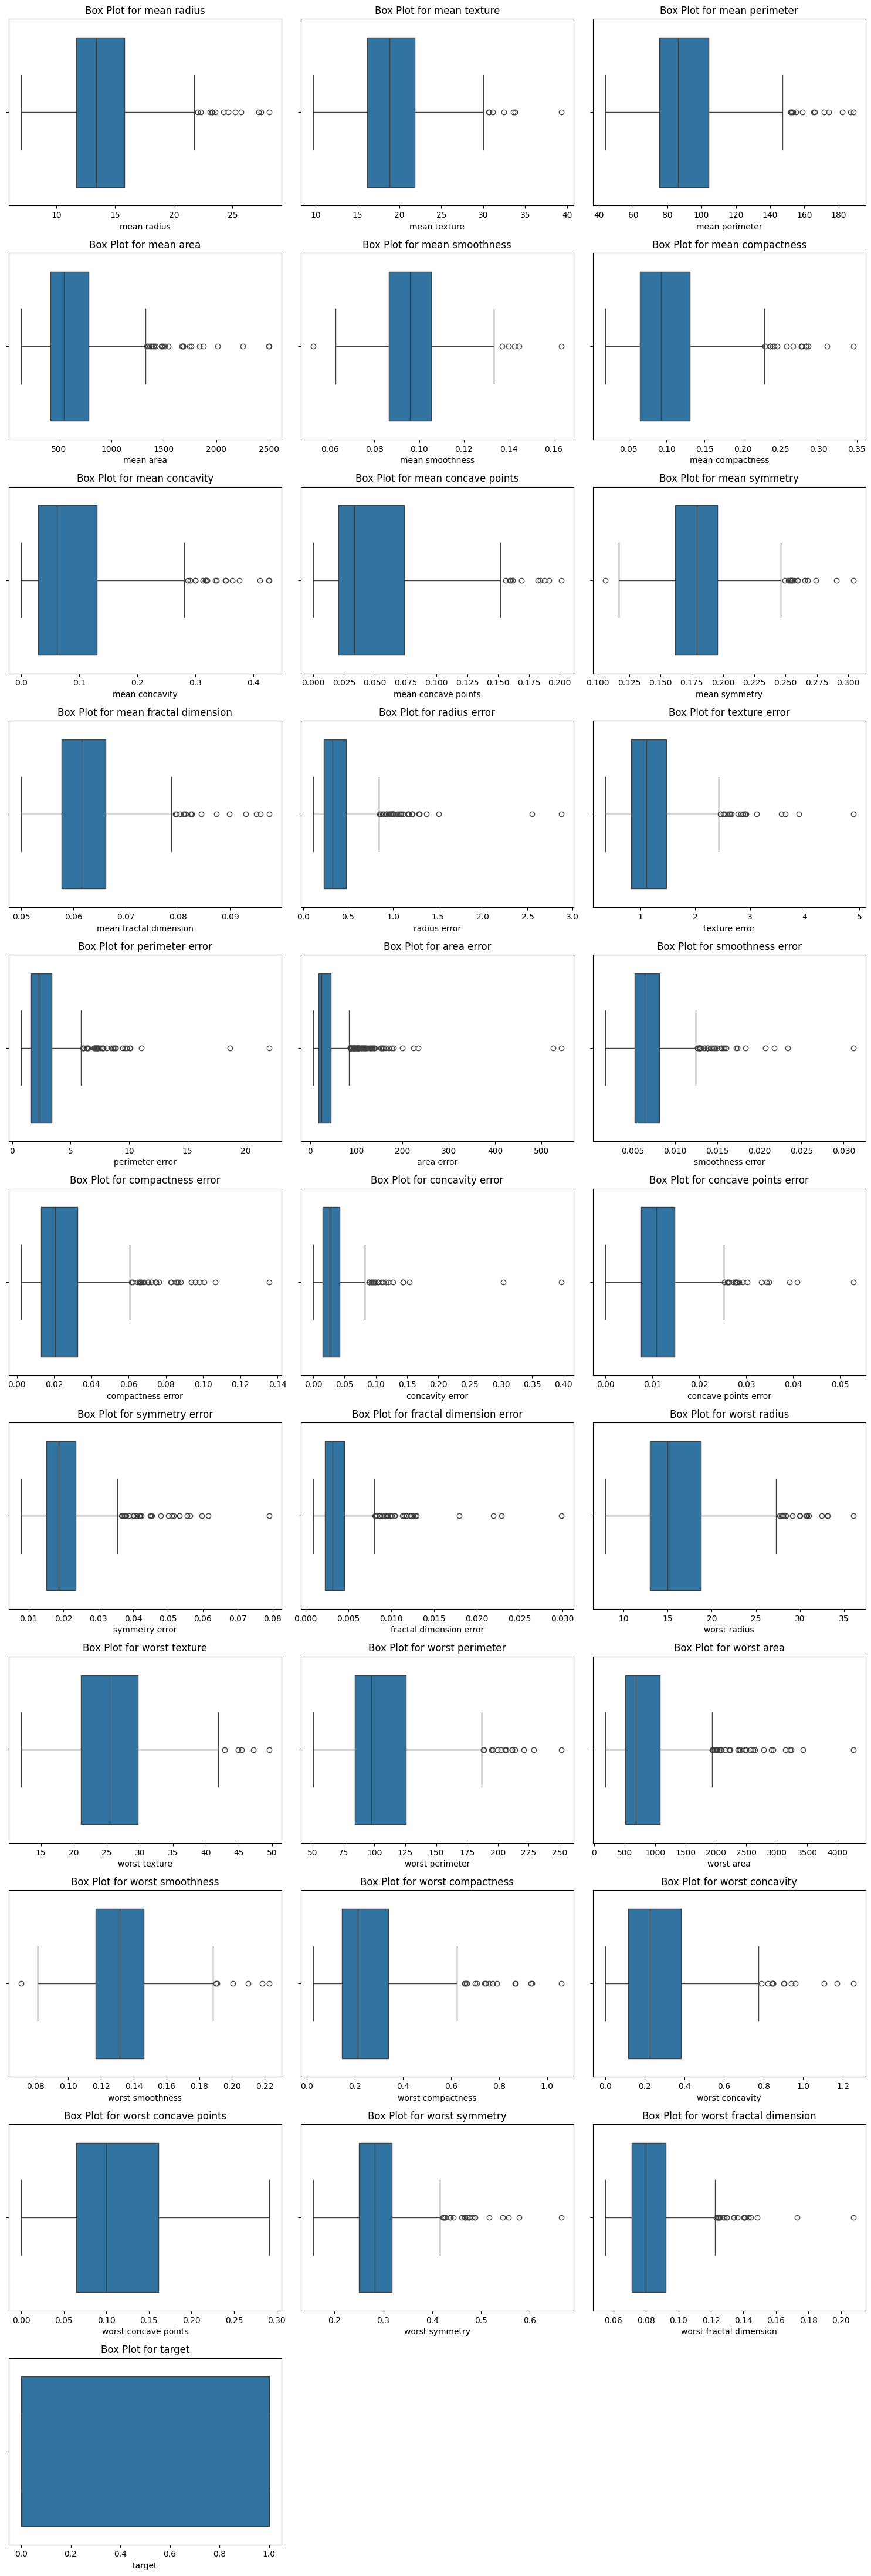

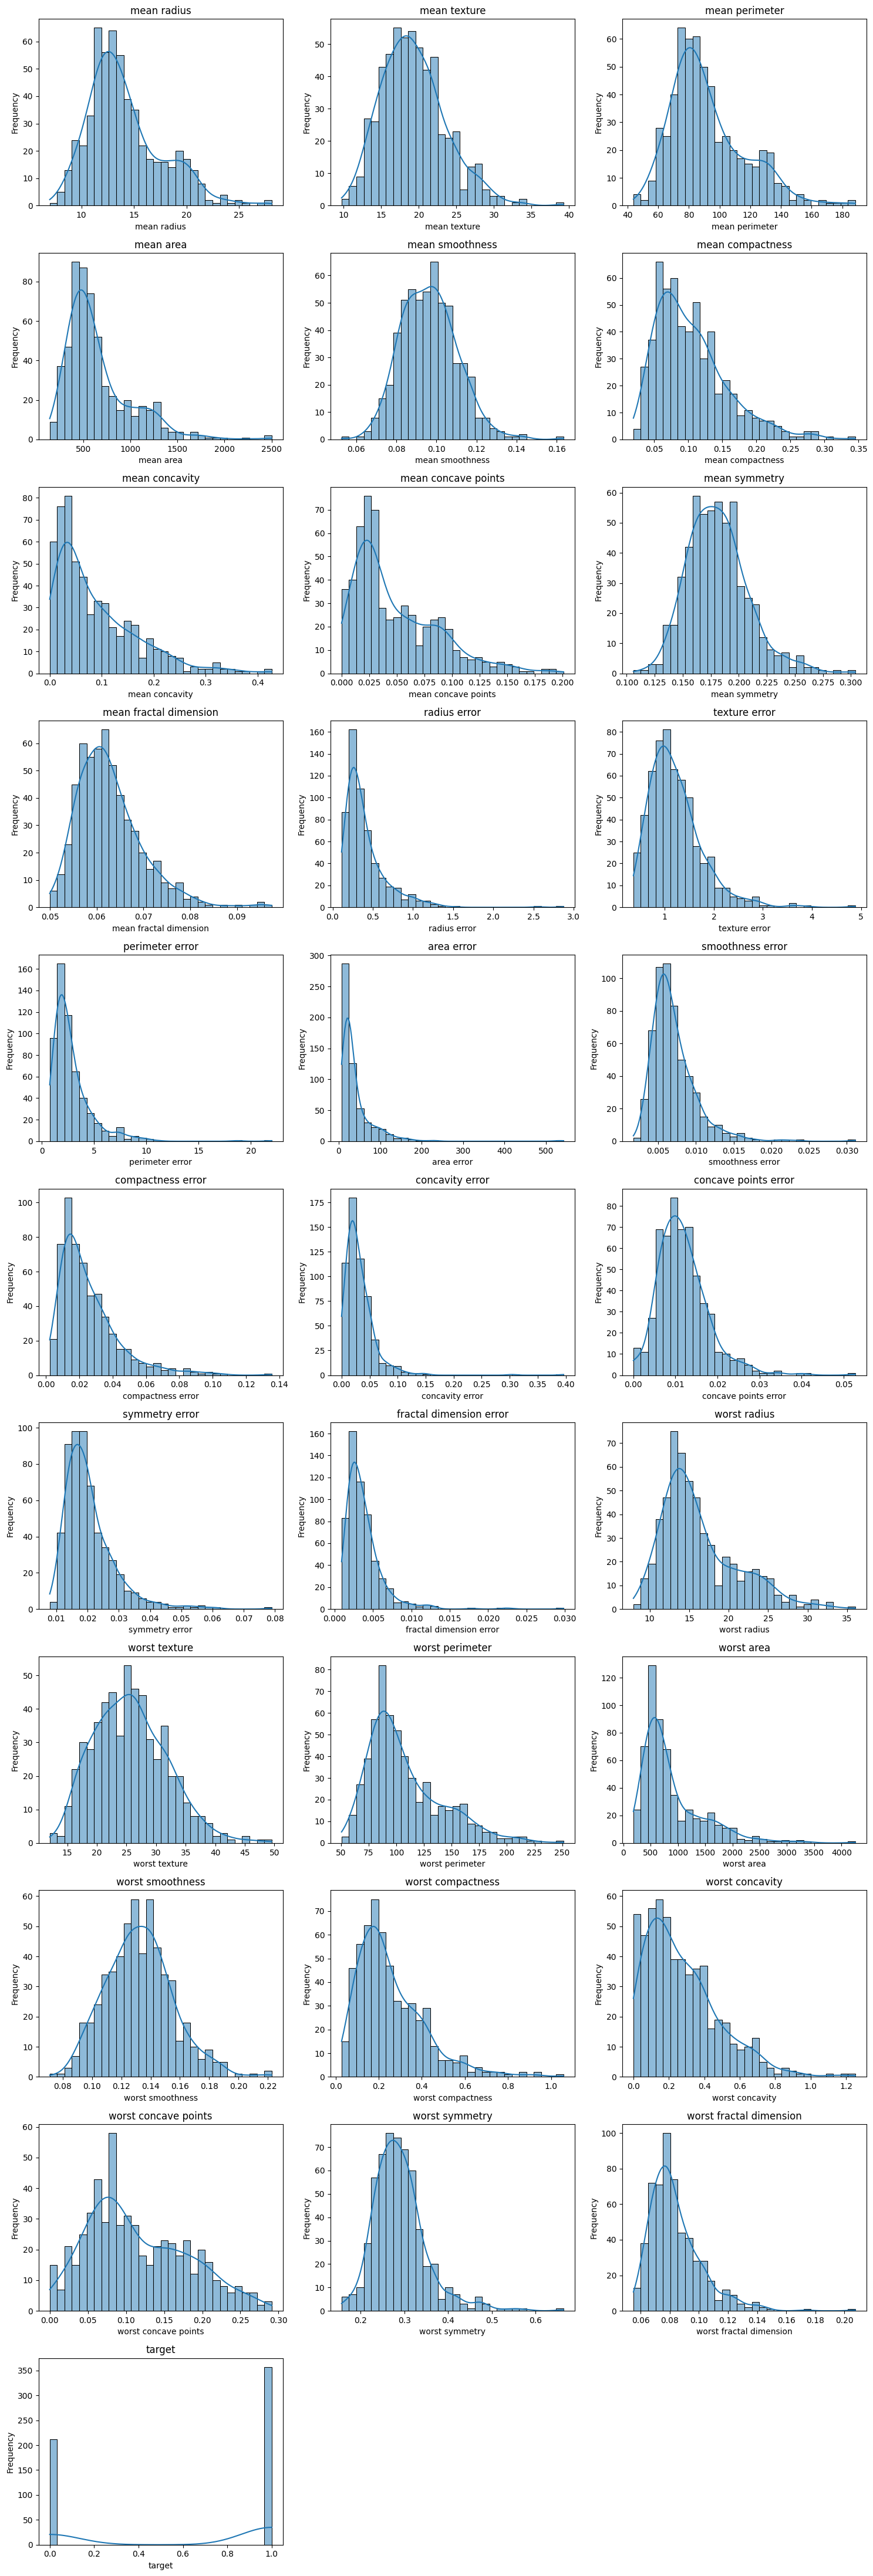

In [41]:

def box_plots(df):
    """
    Display a horizontal box plot for each numeric column in a grid layout.
    Args:
        df (pd.DataFrame): Input DataFrame.
    """
    numeric_cols = df.select_dtypes(include=['number']).columns
    if len(numeric_cols) > 0:
        n_cols = 3
        n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
        axes = axes.flatten()
        for i, col in enumerate(numeric_cols):
            sns.boxplot(x=df[col], orient='h', ax=axes[i])
            axes[i].set_title(f'Box Plot for {col}')
            axes[i].set_xlabel(col)
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
        plt.tight_layout()
        plt.show()
    else:
        print('No numeric columns found.')


def histograms(df):
    """
    Plot histograms (with KDE) for each numeric column in the DataFrame.
    Args:
        df (pd.DataFrame): Input DataFrame.
    """
    numeric_cols = df.select_dtypes(include=['number']).columns
    if len(numeric_cols) > 0:
        n_cols = 3
        n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
        axes = axes.flatten()
        for i, col in enumerate(numeric_cols):
            sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i])
            axes[i].set_title(f'{col}')
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Frequency')
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
        plt.tight_layout()
        plt.show()
    else:
        print('No numeric columns found.')


box_plots(df)
histograms(df)

Standardized the following numeric columns: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


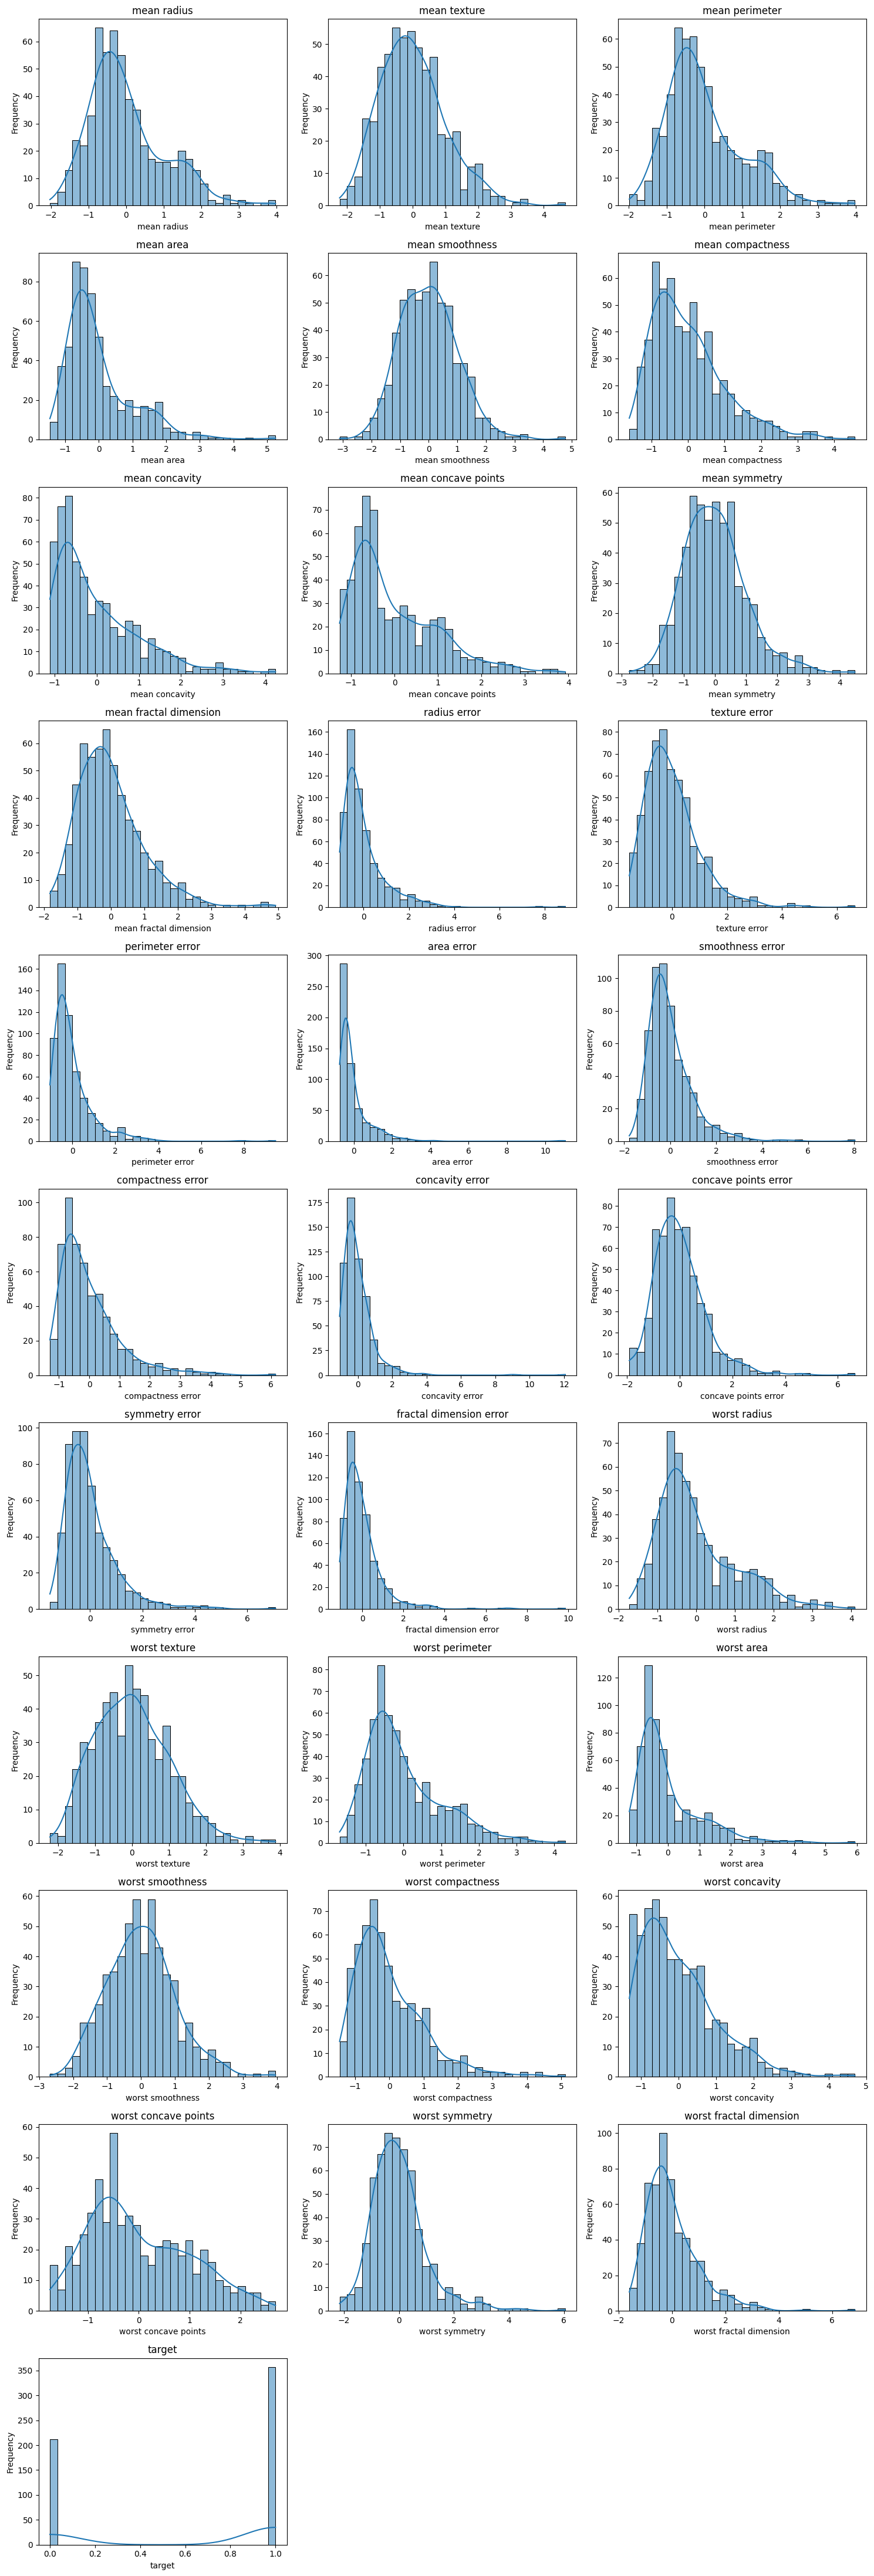

In [42]:
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include='number').columns.drop('target')
scaler = StandardScaler()
df_standardized = df.copy()
df_standardized[numeric_cols] = scaler.fit_transform(df_standardized[numeric_cols])
print('Standardized the following numeric columns:', list(numeric_cols))
histograms(df_standardized)


Most skewed columns to log-transform: ['area error', 'concavity error', 'fractal dimension error', 'perimeter error', 'radius error', 'smoothness error', 'symmetry error', 'compactness error', 'worst area', 'worst fractal dimension']


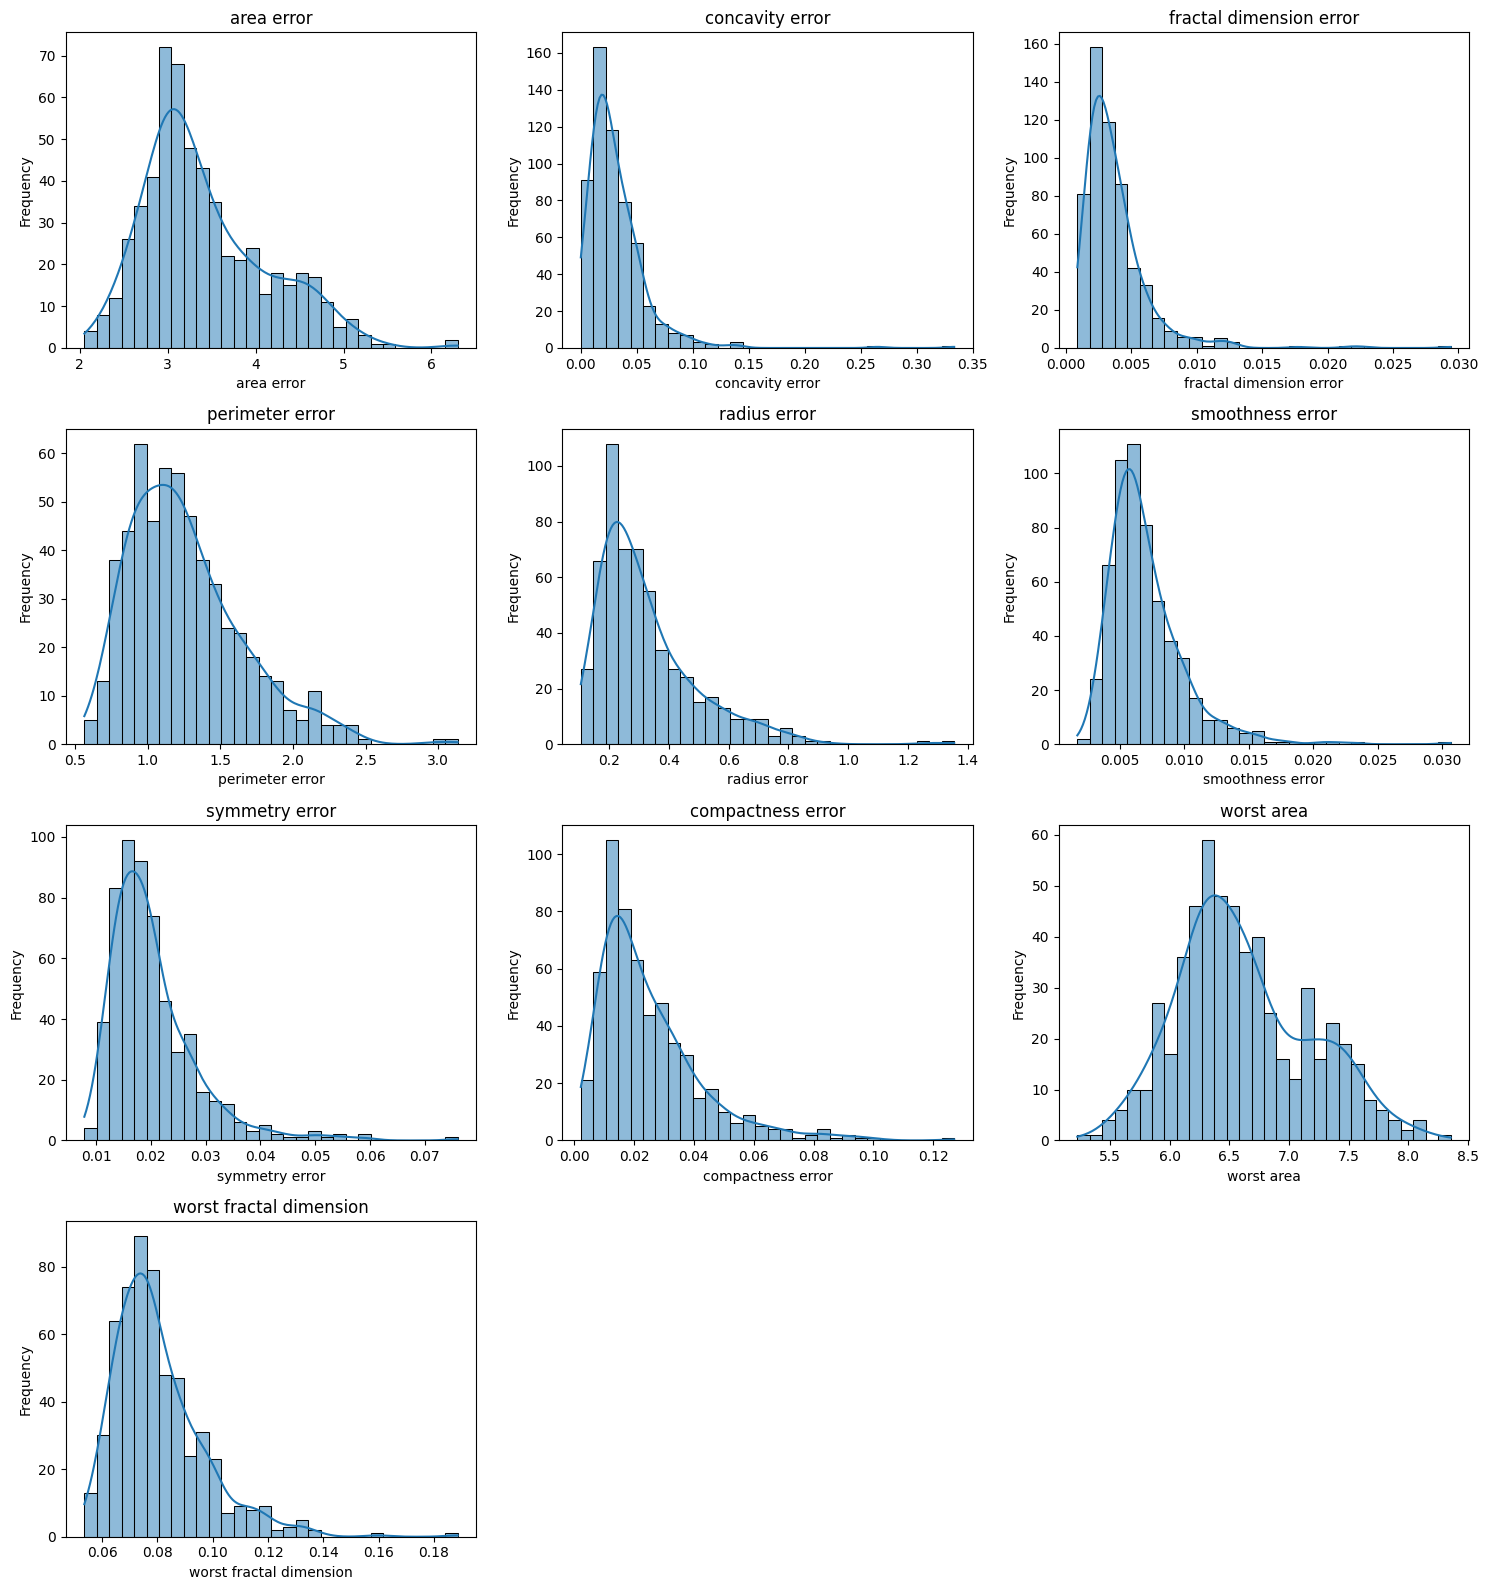

In [43]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Identify the most skewed numeric columns
skewness = df.skew().abs().sort_values(ascending=False)
top_skewed = skewness.head(10).index.tolist()
print('Most skewed columns to log-transform:', top_skewed)

# Apply a safe log1p transform to the most skewed columns
df_log = df.copy()
for col in top_skewed:
    df_log[col] = np.log1p(df_log[col])

# Visualize the transformed distributions for the most skewed features
histograms(df_log[top_skewed])


## MLP Configuration
Define a standard fully connected PyTorch MLP and its training hyperparameters.

In [44]:
mlp_config = {
    "input_dim": len(numeric_cols),
    "hidden_dims": [64, 32],
    "output_dim": 1,
    "activation": nn.ReLU,
    "dropout": 0.3,
    "learning_rate": 1e-3,
    "batch_size": 32,
    "epochs": 25,
    "weight_decay": 1e-5,
    "device": device,
}

print("MLP configuration:")
for k, v in mlp_config.items():
    print(f"  {k}: {v}")

MLP configuration:
  input_dim: 30
  hidden_dims: [64, 32]
  output_dim: 1
  activation: <class 'torch.nn.modules.activation.ReLU'>
  dropout: 0.3
  learning_rate: 0.001
  batch_size: 32
  epochs: 25
  weight_decay: 1e-05
  device: cpu


Epochs:   0%|          | 0/25 [00:00<?, ?epoch/s]

Epoch 1:   0%|          | 0/12 [00:00<?, ?batch/s]

Epoch 01/25 train_loss=0.6001 val_loss=0.6059 train_acc=0.7637 val_acc=0.7363


Epoch 2:   0%|          | 0/12 [00:00<?, ?batch/s]

Epoch 02/25 train_loss=0.5046 val_loss=0.5190 train_acc=0.8956 val_acc=0.8462


...

Epoch 23/25 train_loss=0.0299 val_loss=0.0813 train_acc=0.9918 val_acc=0.9780


Epoch 24:   0%|          | 0/12 [00:00<?, ?batch/s]

Epoch 24/25 train_loss=0.0296 val_loss=0.0812 train_acc=0.9918 val_acc=0.9780


Epoch 25:   0%|          | 0/12 [00:00<?, ?batch/s]

Epoch 25/25 train_loss=0.0266 val_loss=0.0825 train_acc=0.9918 val_acc=0.9780

Final test evaluation
Test loss: 0.1017
Accuracy: 0.956140350877193
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



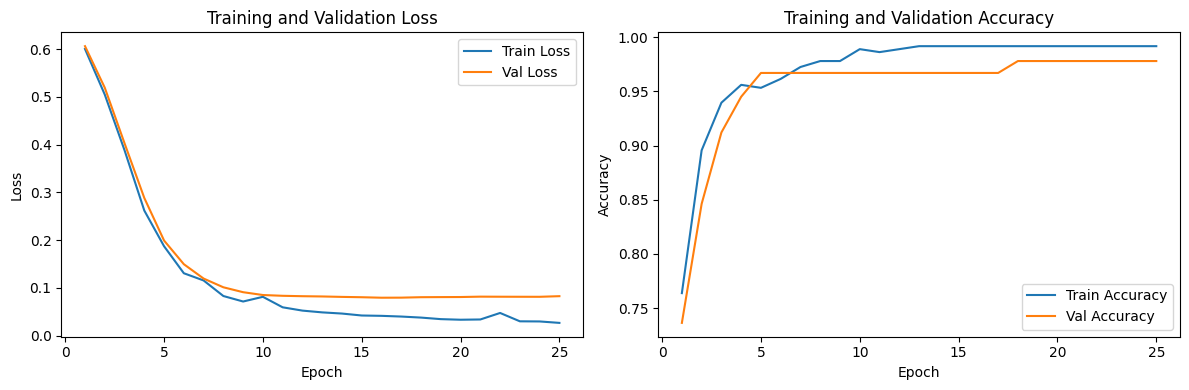

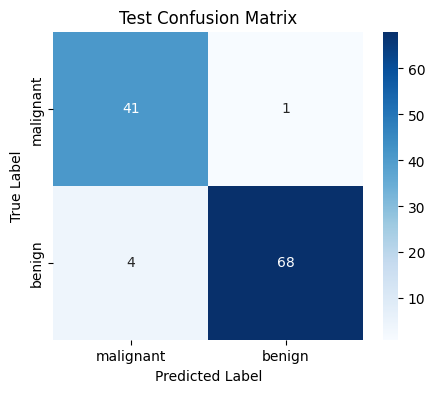

In [45]:
class CancerMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, activation=nn.ReLU, dropout=0.0):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims
        for in_dim, out_dim in zip(dims[:-1], dims[1:]):
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x).squeeze(-1)


# Prepare data for PyTorch
X = df_standardized[numeric_cols].values.astype(np.float32)
y = df_standardized["target"].values.astype(np.float32)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=mlp_config["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=mlp_config["batch_size"], shuffle=False)
test_loader = DataLoader(test_ds, batch_size=mlp_config["batch_size"], shuffle=False)

model = CancerMLP(
    input_dim=mlp_config["input_dim"],
    hidden_dims=mlp_config["hidden_dims"],
    output_dim=mlp_config["output_dim"],
    activation=mlp_config["activation"],
    dropout=mlp_config["dropout"],
).to(mlp_config["device"])

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(
    model.parameters(), lr=mlp_config["learning_rate"], weight_decay=mlp_config["weight_decay"]
)


def evaluate(loader, model_to_eval=None):
    eval_model = model if model_to_eval is None else model_to_eval
    eval_model.eval()
    preds, truths, losses = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(mlp_config["device"])
            y_batch = y_batch.to(mlp_config["device"])
            output = eval_model(X_batch)
            loss = criterion(output, y_batch)
            prob = torch.sigmoid(output)
            preds.extend((prob > 0.5).cpu().numpy().astype(int).tolist())
            truths.extend(y_batch.cpu().numpy().astype(int).tolist())
            losses.append(loss.item())
    return np.array(preds), np.array(truths), np.mean(losses)

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in tqdm(range(1, mlp_config["epochs"] + 1), desc="Epochs", unit="epoch"):
    model.train()
    epoch_losses = []
    for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False, unit="batch"):
        X_batch = X_batch.to(mlp_config["device"])
        y_batch = y_batch.to(mlp_config["device"])
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())

    train_preds, train_truths, train_loss = evaluate(train_loader)
    val_preds, val_truths, val_loss = evaluate(val_loader)
    train_acc = accuracy_score(train_truths, train_preds)
    val_acc = accuracy_score(val_truths, val_preds)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch:02d}/{mlp_config['epochs']} "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
        f"train_acc={train_acc:.4f} val_acc={val_acc:.4f}"
    )

print("\nFinal test evaluation")
test_preds, test_truths, test_loss = evaluate(test_loader)
print("Test loss:", f"{test_loss:.4f}")
print("Accuracy:", accuracy_score(test_truths, test_preds))
print(classification_report(test_truths, test_preds, target_names=data.target_names))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_truths, test_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [46]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

def run_cv(n_splits=5):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_metrics = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), start=1):
        model_cv = CancerMLP(
            input_dim=mlp_config['input_dim'],
            hidden_dims=mlp_config['hidden_dims'],
            output_dim=mlp_config['output_dim'],
            activation=mlp_config['activation'],
            dropout=mlp_config['dropout'],
        ).to(mlp_config['device'])
        optimizer_cv = optim.Adam(
            model_cv.parameters(),
            lr=mlp_config['learning_rate'],
            weight_decay=mlp_config['weight_decay'],
        )
        criterion_cv = nn.BCEWithLogitsLoss()

        X_train_fold = torch.from_numpy(X[train_idx]).float().to(mlp_config['device'])
        y_train_fold = torch.from_numpy(y[train_idx]).float().to(mlp_config['device'])
        X_val_fold = torch.from_numpy(X[val_idx]).float().to(mlp_config['device'])
        y_val_fold = torch.from_numpy(y[val_idx]).float().to(mlp_config['device'])

        train_ds_fold = TensorDataset(X_train_fold, y_train_fold)
        val_ds_fold = TensorDataset(X_val_fold, y_val_fold)
        train_loader_fold = DataLoader(train_ds_fold, batch_size=mlp_config['batch_size'], shuffle=True)
        val_loader_fold = DataLoader(val_ds_fold, batch_size=mlp_config['batch_size'], shuffle=False)

        for epoch in range(1, mlp_config['epochs'] + 1):
            model_cv.train()
            for X_batch, y_batch in train_loader_fold:
                optimizer_cv.zero_grad()
                logits = model_cv(X_batch.to(mlp_config['device']))
                loss = criterion_cv(logits, y_batch.to(mlp_config['device']))
                loss.backward()
                optimizer_cv.step()

        model_cv.eval()
        preds, truths = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader_fold:
                output = model_cv(X_batch.to(mlp_config['device']))
                prob = torch.sigmoid(output)
                preds.extend((prob > 0.5).cpu().numpy().astype(int).tolist())
                truths.extend(y_batch.cpu().numpy().astype(int).tolist())

        fold_metrics.append({
            'fold': fold,
            'accuracy': accuracy_score(truths, preds),
            'f1': f1_score(truths, preds),
            'recall': recall_score(truths, preds),
            'precision': precision_score(truths, preds),
        })

    metrics_df = pd.DataFrame(fold_metrics).set_index('fold')
    print('Cross-validation results:')
    display(metrics_df)
    print('Mean metrics:')
    display(metrics_df.mean().to_frame(name='mean').T)

run_cv(n_splits=5)


Cross-validation results:


,accuracy,f1,recall,precision
fold,,,,
1,0.964912,0.971429,0.957746,0.985507
2,0.973684,0.979310,1.000000,0.959459
3,0.973684,0.979592,1.000000,0.960000
4,0.956140,0.964029,0.930556,1.000000
5,0.991150,0.993007,1.000000,0.986111


Mean metrics:


,accuracy,f1,recall,precision
mean,0.971914,0.977473,0.97766,0.978216


[I 2026-06-02 19:55:40,241] A new study created in memory with name: no-name-82657821-0725-420e-87c9-29929ec4a6ed
[I 2026-06-02 19:55:40,715] Trial 0 finished with value: 0.9743589743589743 and parameters: {'hidden_dim_1': 32, 'hidden_dim_2': 32, 'dropout': 0.4, 'learning_rate': 0.0002751788871163306, 'weight_decay': 8.44454305449533e-05, 'batch_size': 16, 'activation': 'relu'}. Best is trial 0 with value: 0.9743589743589743.
[I 2026-06-02 19:55:40,975] Trial 1 finished with value: 0.9827586206896551 and parameters: {'hidden_dim_1': 64, 'hidden_dim_2': 32, 'dropout': 0.0, 'learning_rate': 0.0006466291199766188, 'weight_decay': 0.00017353595096855314, 'batch_size': 32, 'activation': 'leaky_relu'}. Best is trial 1 with value: 0.9827586206896551.
[I 2026-06-02 19:55:41,447] Trial 2 finished with value: 0.8976377952755905 and parameters: {'hidden_dim_1': 32, 'hidden_dim_2': 16, 'dropout': 0.5, 'learning_rate': 0.0002892307232511722, 'weight_decay': 0.00023880810793824482, 'batch_size': 16,

Best trial:
  Value: 0.9828
  Params:
    hidden_dim_1: 64
    hidden_dim_2: 32
    dropout: 0.0
    learning_rate: 0.0006466291199766188
    weight_decay: 0.00017353595096855314
    batch_size: 32
    activation: leaky_relu

Best model test loss: 0.1135
Best model test accuracy: 0.956140350877193
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        42
      benign       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



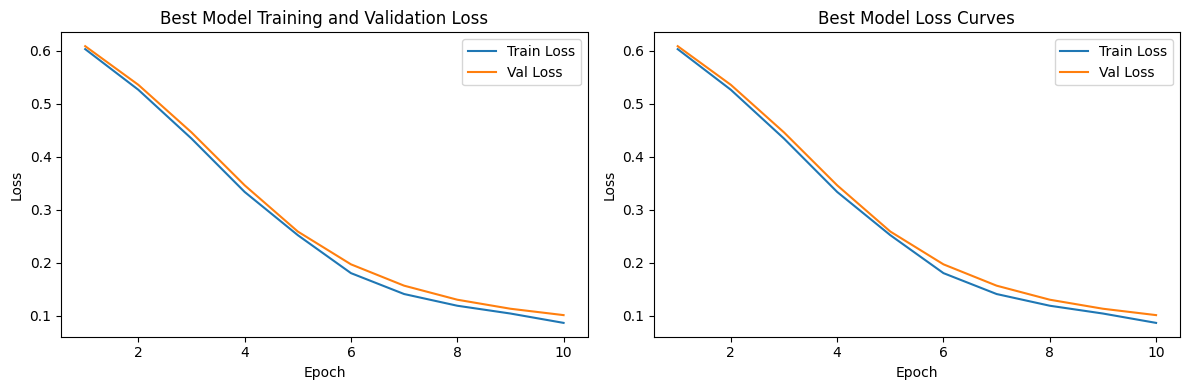

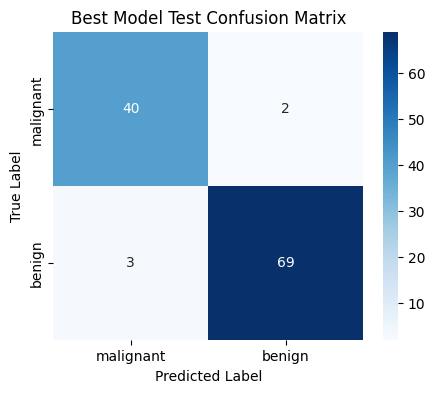

In [47]:
import optuna
import warnings
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

def evaluate_model(loader, model_to_eval):
    model_to_eval.eval()
    preds, truths, losses = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(mlp_config["device"])
            y_batch = y_batch.to(mlp_config["device"])
            output = model_to_eval(X_batch)
            loss = criterion(output, y_batch)
            prob = torch.sigmoid(output)
            preds.extend((prob > 0.5).cpu().numpy().astype(int).tolist())
            truths.extend(y_batch.cpu().numpy().astype(int).tolist())
            losses.append(loss.item())
    return np.array(preds), np.array(truths), np.mean(losses)

def objective(trial):
    hidden_dims = [
        trial.suggest_categorical("hidden_dim_1", [32, 64, 128]),
        trial.suggest_categorical("hidden_dim_2", [16, 32, 64]),
    ]
    dropout = trial.suggest_float("dropout", 0.0, 0.5, step=0.1)
    lr = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    activation = nn.ReLU if trial.suggest_categorical("activation", ["relu", "leaky_relu"]) == "relu" else nn.LeakyReLU

    train_loader_opt = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader_opt = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
    )

    model_opt = CancerMLP(
        input_dim=mlp_config["input_dim"],
        hidden_dims=hidden_dims,
        output_dim=mlp_config["output_dim"],
        activation=activation,
        dropout=dropout,
    ).to(mlp_config["device"])

    optimizer_opt = optim.Adam(model_opt.parameters(), lr=lr, weight_decay=weight_decay)
    criterion_opt = nn.BCEWithLogitsLoss()

    for epoch in range(1, 11):
        model_opt.train()
        for X_batch, y_batch in train_loader_opt:
            X_batch = X_batch.to(mlp_config["device"])
            y_batch = y_batch.to(mlp_config["device"])
            optimizer_opt.zero_grad()
            logits = model_opt(X_batch)
            loss = criterion_opt(logits, y_batch)
            loss.backward()
            optimizer_opt.step()

    val_preds_opt, val_truths_opt, val_loss_opt = evaluate_model(val_loader_opt, model_opt)
    trial.set_user_attr("val_loss", val_loss_opt)
    return f1_score(val_truths_opt, val_preds_opt)

study = optuna.create_study(direction="maximize")
num_trials = 60
study.optimize(
    objective,
    n_trials=num_trials,
    timeout=600,
)

print("Best trial:")
print(f"  Value: {study.best_value:.4f}")
print("  Params:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

best_params = study.best_params
best_model = CancerMLP(
    input_dim=mlp_config["input_dim"],
    hidden_dims=[best_params["hidden_dim_1"], best_params["hidden_dim_2"]],
    output_dim=mlp_config["output_dim"],
    activation=nn.ReLU if best_params["activation"] == "relu" else nn.LeakyReLU,
    dropout=best_params["dropout"],
).to(mlp_config["device"])

best_optimizer = optim.Adam(
    best_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"]
)

best_train_losses = []
best_val_losses = []

best_train_loader = DataLoader(
    train_ds,
    batch_size=best_params["batch_size"],
    shuffle=True,
)
best_val_loader = DataLoader(
    val_ds,
    batch_size=best_params["batch_size"],
    shuffle=False,
)

for epoch in range(1, 11):
    best_model.train()
    for X_batch, y_batch in best_train_loader:
        X_batch = X_batch.to(mlp_config["device"])
        y_batch = y_batch.to(mlp_config["device"])
        best_optimizer.zero_grad()
        logits = best_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        best_optimizer.step()

    _, _, train_loss = evaluate_model(best_train_loader, best_model)
    _, _, val_loss = evaluate_model(best_val_loader, best_model)
    best_train_losses.append(train_loss)
    best_val_losses.append(val_loss)

best_test_loader = DataLoader(
    test_ds,
    batch_size=best_params["batch_size"],
    shuffle=False,
)
best_preds, best_truths, best_test_loss = evaluate_model(best_test_loader, best_model)
print("\nBest model test loss:", f"{best_test_loss:.4f}")
print("Best model test accuracy:", accuracy_score(best_truths, best_preds))
print(classification_report(best_truths, best_preds, target_names=data.target_names))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(best_train_losses) + 1), best_train_losses, label='Train Loss')
plt.plot(range(1, len(best_val_losses) + 1), best_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Best Model Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(best_train_losses) + 1), best_train_losses, label='Train Loss')
plt.plot(range(1, len(best_val_losses) + 1), best_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Best Model Loss Curves')
plt.legend()
plt.tight_layout()
plt.show()

cm_best = confusion_matrix(best_truths, best_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Best Model Test Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


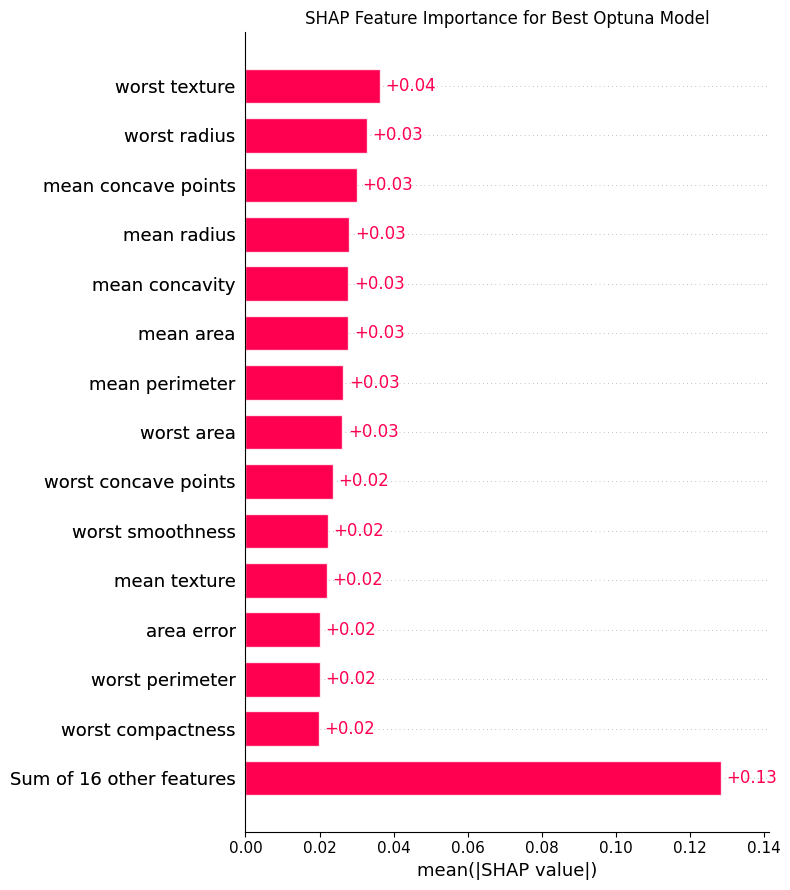

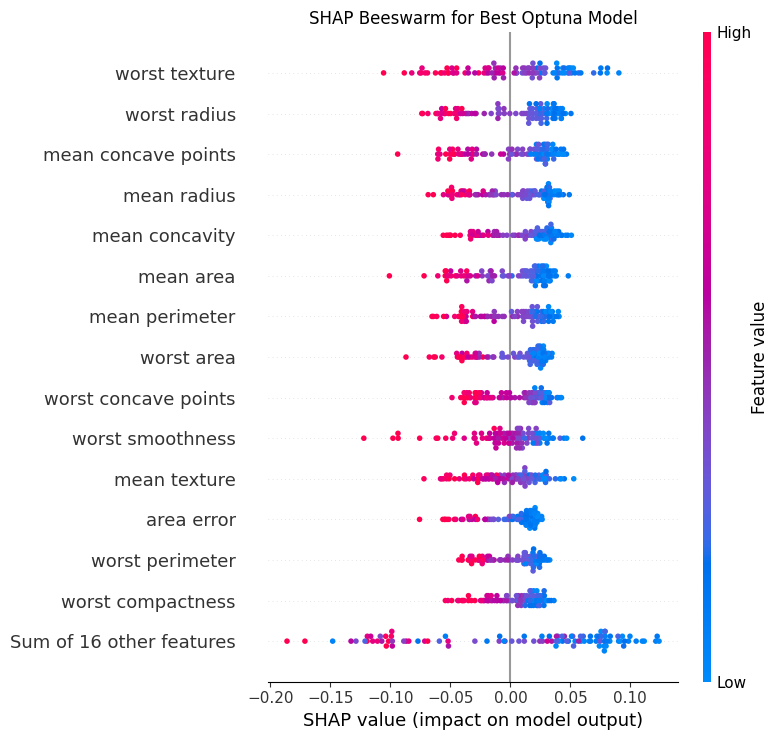

In [50]:
try:
    import shap
except ImportError:
    import sys
    !{sys.executable} -m pip install shap
    import shap

# Use a CPU copy of the best model for SHAP explanation
best_model_cpu = best_model.to('cpu')
best_model_cpu.eval()
X_explain_np = X_train[:100].astype(np.float32)
X_test_subset_np = X_test[:100].astype(np.float32)

def model_predict(x):
    x_tensor = torch.from_numpy(np.array(x, dtype=np.float32))
    with torch.no_grad():
        logits = best_model_cpu(x_tensor)
        return torch.sigmoid(logits).cpu().numpy()

explainer = shap.Explainer(model_predict, X_explain_np, feature_names=list(numeric_cols))
shap_values = explainer(X_test_subset_np)

plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('SHAP Feature Importance for Best Optuna Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Beeswarm for Best Optuna Model')
plt.tight_layout()
plt.show()


In [ ]:
from IPython.display import Markdown, display
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

try:
    test_accuracy = accuracy_score(best_truths, best_preds)
    test_f1 = f1_score(best_truths, best_preds)
    test_recall = recall_score(best_truths, best_preds)
    test_precision = precision_score(best_truths, best_preds)
except NameError:
    test_accuracy = test_f1 = test_recall = test_precision = None

model_card = f"""# Model Card

## Dataset
- Wisconsin Breast Cancer dataset
- Samples: {len(X)}
- Features: {len(numeric_cols)}
- Classes: 2 (malignant / benign)

## Model
- PyTorch MLP with hidden layers {mlp_config['hidden_dims']}
- Activation: {mlp_config['activation'].__name__}
- Dropout: {mlp_config['dropout']}
- Optimizer: Adam, lr={mlp_config['learning_rate']}, weight_decay={mlp_config['weight_decay']}
- Batch size: {mlp_config['batch_size']}
- Epochs: {mlp_config['epochs']}

## Optuna Tuning
- Objective: maximize F1 score on validation data
- Trials: {num_trials if 'num_trials' in globals() else 'N/A'}
- Best F1: {f"{study.best_value:.4f}" if 'study' in globals() else 'N/A'}
- Best parameters: {study.best_params if 'study' in globals() else 'N/A'}

## Evaluation
- Test accuracy: {test_accuracy if test_accuracy is not None else 'N/A'}
- Test F1: {test_f1 if test_f1 is not None else 'N/A'}
- Test recall: {test_recall if test_recall is not None else 'N/A'}
- Test precision: {test_precision if test_precision is not None else 'N/A'}

## Notes
- SHAP analysis was generated for the Optuna-derived best model.
- A 5-fold cross-validation cell exists earlier in the notebook for robust estimates.

## Current State
- Model training is completed through Optuna tuning and the best model is evaluated on the test set.
- Use the cross-validation output cell to compare fold-level stability.
"""

display(Markdown(model_card))


# Model Card

## Dataset
- Wisconsin Breast Cancer dataset
- Samples: 569
- Features: 30
- Classes: 2 (malignant / benign)

## Model
- PyTorch MLP with hidden layers [64, 32]
- Activation: ReLU
- Dropout: 0.3
- Optimizer: Adam, lr=0.001, weight_decay=1e-05
- Batch size: 32
- Epochs: 25

## Optuna Tuning
- Objective: maximize F1 score on validation data
- Trials: 60
- Best F1: 0.9828
- Best parameters: {'hidden_dim_1': 64, 'hidden_dim_2': 32, 'dropout': 0.0, 'learning_rate': 0.0006466291199766188, 'weight_decay': 0.00017353595096855314, 'batch_size': 32, 'activation': 'leaky_relu'}

## Evaluation
- Test accuracy: 0.956140350877193
- Test F1: 0.965034965034965
- Test recall: 0.9583333333333334
- Test precision: 0.971830985915493

## Notes
- SHAP analysis was generated for the Optuna-derived best model.
- A 5-fold cross-validation cell exists earlier in the notebook for robust estimates.

## Current State
- Model training is completed through Optuna tuning and the best model is evaluated on the test set.
- Use the cross-validation output cell to compare fold-level stability.
